# PLS-SEM — Modelo 7S → Technology Protection

Este notebook calcula os escores latentes dos constructos, estima os coeficientes estruturais padronizados, calcula confiabilidade composta (CR), AVE, R²/R² ajustado e gera:

1. Diagrama PLS-SEM em Markdown/Mermaid
2. Tabela de hipóteses com β, p-value bootstrap e conclusão

> Requisito: Python 3.12 com `pandas`, `numpy` e `IPython`.


In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Ajuste o caminho se o CSV estiver em outro diretório.
CSV_PATH = Path("inputs/questionario_sintetico.csv")

# Fallback útil para execução no ambiente do ChatGPT.
# if not CSV_PATH.exists():
#     CSV_PATH = Path("/mnt/data/questionario_sintetico.csv")

if not CSV_PATH.exists():
    raise FileNotFoundError(
        "Arquivo CSV não encontrado. Coloque 'questionario_sintetico.csv' "
        "no mesmo diretório do notebook ou ajuste CSV_PATH."
    )

df = pd.read_csv(CSV_PATH)

print(f"Dimensões do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head())


Dimensões do dataset: 100 linhas x 35 colunas


,Perfil,sexo,idade,SV1,SV2,SV3,SV4,SG1,SG2,SG3,...,SY3,SY4,SK1,SK2,SK3,SK4,TP1,TP2,TP3,TP4
0,1,Masculino,44,6,5,7,5,5,6,5,...,5,5,5,4,4,4,5,4,4,4
1,2,Masculino,45,6,5,7,5,4,5,4,...,4,4,4,3,3,2,4,3,4,3
2,3,Masculino,25,7,6,7,6,5,6,5,...,5,5,6,5,4,4,5,4,4,4
3,4,Masculino,27,6,6,7,5,6,6,6,...,5,5,6,5,5,4,5,4,4,4
4,5,Masculino,37,6,5,7,5,6,6,6,...,5,6,6,5,5,4,5,4,4,4


In [3]:
# Especificação do modelo com base na proposta do artigo:
# sete constructos do modelo 7S como antecedentes de Technology Protection.

constructs = {
    "SV": ["SV1", "SV2", "SV3", "SV4"],  # Shared Values
    "SG": ["SG1", "SG2", "SG3", "SG4"],  # Strategy
    "SU": ["SU1", "SU2", "SU3", "SU4"],  # Structure
    "SM": ["SM1", "SM2", "SM3", "SM4"],  # Systems
    "SF": ["SF1", "SF2", "SF3", "SF4"],  # Staff
    "SY": ["SY1", "SY2", "SY3", "SY4"],  # Style
    "SK": ["SK1", "SK2", "SK3", "SK4"],  # Skills
    "TP": ["TP1", "TP2", "TP3", "TP4"],  # Technology Protection
}

labels = {
    "SV": "Shared Values",
    "SG": "Strategy",
    "SU": "Structure",
    "SM": "Systems",
    "SF": "Staff",
    "SY": "Style",
    "SK": "Skills",
    "TP": "Technology Protection",
}

hypotheses = {
    "SV": "H1",
    "SG": "H2",
    "SU": "H3",
    "SM": "H4",
    "SF": "H5",
    "SY": "H6",
    "SK": "H7",
}

predictors = ["SV", "SG", "SU", "SM", "SF", "SY", "SK"]
target = "TP"

required_columns = [item for items in constructs.values() for item in items]
missing_columns = sorted(set(required_columns) - set(df.columns))

if missing_columns:
    raise ValueError(f"Colunas ausentes no CSV: {missing_columns}")

print("Constructos e indicadores validados.")


Constructos e indicadores validados.


In [4]:
def make_latent_scores(
    data: pd.DataFrame, model_constructs: dict[str, list[str]]
) -> pd.DataFrame:
    """Calcula os escores latentes por média simples dos itens de cada constructo."""
    return pd.DataFrame(
        {
            construct: data[items].mean(axis=1)
            for construct, items in model_constructs.items()
        },
        index=data.index,
    )


def standardize(data: pd.DataFrame) -> pd.DataFrame:
    """Padroniza variáveis com média 0 e desvio-padrão populacional 1."""
    return (data - data.mean(axis=0)) / data.std(axis=0, ddof=0)


def estimate_structural_paths(
    score_data: pd.DataFrame,
    x_constructs: list[str],
    y_construct: str,
) -> tuple[pd.Series, float, float]:
    """Estima coeficientes padronizados de caminho e R² por regressão OLS sobre escores latentes."""
    z = standardize(score_data[x_constructs + [y_construct]])

    X = z[x_constructs].to_numpy(dtype=float)
    y = z[y_construct].to_numpy(dtype=float)

    # Como as variáveis estão padronizadas, o intercepto é zero.
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta

    sse = float(np.sum((y - y_hat) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2))
    r2 = 1 - (sse / sst)

    n = len(y)
    k = len(x_constructs)
    r2_adj = 1 - (1 - r2) * (n - 1) / (n - k - 1)

    return pd.Series(beta, index=x_constructs, name="beta"), r2, r2_adj


def reliability_metrics(
    original_data: pd.DataFrame,
    score_data: pd.DataFrame,
    model_constructs: dict[str, list[str]],
) -> pd.DataFrame:
    """Calcula cargas externas, confiabilidade composta (CR) e AVE."""
    rows = []

    for construct, items in model_constructs.items():
        latent_score = score_data[construct]

        # Carga externa aproximada: correlação item-escore latente.
        loadings = original_data[items].apply(lambda col: col.corr(latent_score))

        ave = float(np.mean(loadings**2))
        cr = float(
            (loadings.sum() ** 2) / ((loadings.sum() ** 2) + np.sum(1 - loadings**2))
        )

        rows.append(
            {
                "Constructo": construct,
                "Nome": labels.get(construct, construct),
                "CR": cr,
                "AVE": ave,
                "Cargas": ", ".join(f"{item}={loadings[item]:.3f}" for item in items),
            }
        )

    return pd.DataFrame(rows)


def bootstrap_paths(
    score_data: pd.DataFrame,
    x_constructs: list[str],
    y_construct: str,
    n_boot: int = 5_000,
    seed: int = 42,
) -> pd.DataFrame:
    """Bootstrap dos coeficientes estruturais.

    O p-value é calculado por aproximação normal usando:
    t = beta_original / erro_padrao_bootstrap
    p = 2 * P(Z >= |t|)
    """
    rng = np.random.default_rng(seed)

    cols = x_constructs + [y_construct]
    matrix = score_data[cols].to_numpy(dtype=float)
    n = matrix.shape[0]
    k = len(x_constructs)

    def beta_from_matrix(m: np.ndarray) -> np.ndarray:
        z = (m - m.mean(axis=0)) / m.std(axis=0, ddof=0)
        X = z[:, :k]
        y = z[:, k]
        return np.linalg.lstsq(X, y, rcond=None)[0]

    beta_original = beta_from_matrix(matrix)

    boot_betas = np.empty((n_boot, k), dtype=float)
    for i in range(n_boot):
        sample_idx = rng.integers(0, n, size=n)
        boot_betas[i, :] = beta_from_matrix(matrix[sample_idx, :])

    se_boot = boot_betas.std(axis=0, ddof=1)
    t_values = beta_original / se_boot

    # p-value bicaudal por aproximação normal padrão.
    p_values = np.array([math.erfc(abs(t) / math.sqrt(2)) for t in t_values])

    return pd.DataFrame(
        {
            "Constructo": x_constructs,
            "beta": beta_original,
            "SE_boot": se_boot,
            "t_boot": t_values,
            "p_boot": p_values,
        }
    )


In [5]:
# Cálculo dos resultados

scores = make_latent_scores(df, constructs)
betas, r2, r2_adj = estimate_structural_paths(scores, predictors, target)
reliability = reliability_metrics(df, scores, constructs)
boot = bootstrap_paths(scores, predictors, target, n_boot=5_000, seed=42)

results = boot.assign(
    Hipótese=lambda x: x["Constructo"].map(hypotheses),
    Caminho=lambda x: x["Constructo"].map(lambda c: f"{c} → TP"),
    Resultado=lambda x: np.where(
        (x["beta"] > 0) & (x["p_boot"] < 0.05), "Suportada", "Não suportada"
    ),
)[
    [
        "Constructo",
        "Hipótese",
        "Caminho",
        "beta",
        "SE_boot",
        "t_boot",
        "p_boot",
        "Resultado",
    ]
]

print(f"R² = {r2:.3f}")
print(f"R² ajustado = {r2_adj:.3f}")

display(
    results.drop(columns=["Constructo"]).style.format(
        {
            "beta": "{:.3f}",
            "SE_boot": "{:.3f}",
            "t_boot": "{:.3f}",
            "p_boot": "{:.3f}",
        }
    )
)

display(
    reliability.style.format(
        {
            "CR": "{:.3f}",
            "AVE": "{:.3f}",
        }
    )
)


R² = 0.554
R² ajustado = 0.520


,Hipótese,Caminho,beta,SE_boot,t_boot,p_boot,Resultado
0,H1,SV → TP,-0.049,0.085,-0.572,0.567,Não suportada
1,H2,SG → TP,0.292,0.132,2.204,0.028,Suportada
2,H3,SU → TP,0.015,0.128,0.119,0.906,Não suportada
3,H4,SM → TP,0.235,0.082,2.868,0.004,Suportada
4,H5,SF → TP,0.039,0.119,0.325,0.745,Não suportada
5,H6,SY → TP,0.098,0.086,1.149,0.250,Não suportada
6,H7,SK → TP,0.228,0.102,2.240,0.025,Suportada


,Constructo,Nome,CR,AVE,Cargas
0,SV,Shared Values,0.750,0.438,"SV1=0.644, SV2=0.768, SV3=0.441, SV4=0.744"
1,SG,Strategy,0.865,0.626,"SG1=0.891, SG2=0.495, SG3=0.913, SG4=0.795"
2,SU,Structure,0.907,0.711,"SU1=0.827, SU2=0.884, SU3=0.888, SU4=0.768"
3,SM,Systems,0.756,0.437,"SM1=0.725, SM2=0.677, SM3=0.600, SM4=0.636"
4,SF,Staff,0.876,0.640,"SF1=0.753, SF2=0.830, SF3=0.888, SF4=0.719"
5,SY,Style,0.854,0.595,"SY1=0.672, SY2=0.805, SY3=0.800, SY4=0.801"
6,SK,Skills,0.867,0.622,"SK1=0.687, SK2=0.859, SK3=0.842, SK4=0.755"
7,TP,Technology Protection,0.833,0.557,"TP1=0.832, TP2=0.720, TP3=0.776, TP4=0.645"


In [6]:
def build_mermaid_diagram(
    path_results: pd.DataFrame,
    reliability_table: pd.DataFrame,
    r2_value: float,
    r2_adj_value: float,
) -> str:
    """Gera o diagrama Mermaid do modelo PLS-SEM."""
    rel = reliability_table.set_index("Constructo")
    paths = path_results.set_index("Constructo")

    def fmt(value: float) -> str:
        return f"{value:.3f}"

    lines = ["flowchart LR"]

    # Nós dos constructos independentes
    for c in predictors:
        lines.append(
            f'    {c}["{labels[c]}<br/>{c}<br/>'
            f'CR={fmt(rel.loc[c, "CR"])} | AVE={fmt(rel.loc[c, "AVE"])}"]'
        )

    # Nó da variável dependente
    lines.append(
        f'    TP["{labels["TP"]}<br/>TP<br/>'
        f"R²={fmt(r2_value)} | R² ajust.={fmt(r2_adj_value)}<br/>"
        f'CR={fmt(rel.loc["TP", "CR"])} | AVE={fmt(rel.loc["TP", "AVE"])}"]'
    )

    lines.append("")

    # Arestas estruturais
    for c in predictors:
        h = hypotheses[c]
        beta = paths.loc[c, "beta"]
        p_value = paths.loc[c, "p_boot"]
        lines.append(f'    {c} -->|"{h}: β={fmt(beta)}; p={fmt(p_value)}"| TP')

    return "```mermaid\n" + "\n".join(lines) + "\n```"


mermaid_graph = build_mermaid_diagram(results, reliability, r2, r2_adj)

# Exibe no notebook. Em ambientes com suporte a Mermaid, o gráfico será renderizado.
display(Markdown(mermaid_graph))

# Também imprime o código Markdown/Mermaid para copiar em editores compatíveis.
print(mermaid_graph)


```mermaid
flowchart LR
    SV["Shared Values<br/>SV<br/>CR=0.750 | AVE=0.438"]
    SG["Strategy<br/>SG<br/>CR=0.865 | AVE=0.626"]
    SU["Structure<br/>SU<br/>CR=0.907 | AVE=0.711"]
    SM["Systems<br/>SM<br/>CR=0.756 | AVE=0.437"]
    SF["Staff<br/>SF<br/>CR=0.876 | AVE=0.640"]
    SY["Style<br/>SY<br/>CR=0.854 | AVE=0.595"]
    SK["Skills<br/>SK<br/>CR=0.867 | AVE=0.622"]
    TP["Technology Protection<br/>TP<br/>R²=0.554 | R² ajust.=0.520<br/>CR=0.833 | AVE=0.557"]

    SV -->|"H1: β=-0.049; p=0.567"| TP
    SG -->|"H2: β=0.292; p=0.028"| TP
    SU -->|"H3: β=0.015; p=0.906"| TP
    SM -->|"H4: β=0.235; p=0.004"| TP
    SF -->|"H5: β=0.039; p=0.745"| TP
    SY -->|"H6: β=0.098; p=0.250"| TP
    SK -->|"H7: β=0.228; p=0.025"| TP
```

```mermaid
flowchart LR
    SV["Shared Values<br/>SV<br/>CR=0.750 | AVE=0.438"]
    SG["Strategy<br/>SG<br/>CR=0.865 | AVE=0.626"]
    SU["Structure<br/>SU<br/>CR=0.907 | AVE=0.711"]
    SM["Systems<br/>SM<br/>CR=0.756 | AVE=0.437"]
    SF["Staff<br/>SF<br/>CR=0.876 | AVE=0.640"]
    SY["Style<br/>SY<br/>CR=0.854 | AVE=0.595"]
    SK["Skills<br/>SK<br/>CR=0.867 | AVE=0.622"]
    TP["Technology Protection<br/>TP<br/>R²=0.554 | R² ajust.=0.520<br/>CR=0.833 | AVE=0.557"]

    SV -->|"H1: β=-0.049; p=0.567"| TP
    SG -->|"H2: β=0.292; p=0.028"| TP
    SU -->|"H3: β=0.015; p=0.906"| TP
    SM -->|"H4: β=0.235; p=0.004"| TP
    SF -->|"H5: β=0.039; p=0.745"| TP
    SY -->|"H6: β=0.098; p=0.250"| TP
    SK -->|"H7: β=0.228; p=0.025"| TP
```


In [7]:
# Tabela final formatada, igual à estrutura usada no artigo/relatório.

table_final = results[["Hipótese", "Caminho", "beta", "p_boot", "Resultado"]].rename(
    columns={
        "beta": "β",
        "p_boot": "p boot",
    }
)

display(
    table_final.style.format(
        {
            "β": "{:.3f}",
            "p boot": "{:.3f}",
        }
    )
)

# Exporta os artefatos auxiliares, caso deseje usar em relatório.
table_final.to_csv("outputs/tabela_pls_sem.csv", index=False, encoding="utf-8-sig")
Path("outputs/grafico_pls_sem_mermaid.md").write_text(mermaid_graph, encoding="utf-8")

print("Arquivos gerados:")
print("- tabela_pls_sem.csv")
print("- grafico_pls_sem_mermaid.md")


,Hipótese,Caminho,β,p boot,Resultado
0,H1,SV → TP,-0.049,0.567,Não suportada
1,H2,SG → TP,0.292,0.028,Suportada
2,H3,SU → TP,0.015,0.906,Não suportada
3,H4,SM → TP,0.235,0.004,Suportada
4,H5,SF → TP,0.039,0.745,Não suportada
5,H6,SY → TP,0.098,0.250,Não suportada
6,H7,SK → TP,0.228,0.025,Suportada


Arquivos gerados:
- tabela_pls_sem.csv
- grafico_pls_sem_mermaid.md


## Exportar o gráfico PLS-SEM para PNG

Esta seção salva o diagrama do modelo em `grafico_pls_sem.png` no diretório local do notebook.

O código usa `matplotlib` para gerar uma imagem PNG diretamente, sem depender de internet ou de renderizadores externos de Mermaid. O arquivo Mermaid original continua sendo salvo em `grafico_pls_sem_mermaid.md`.


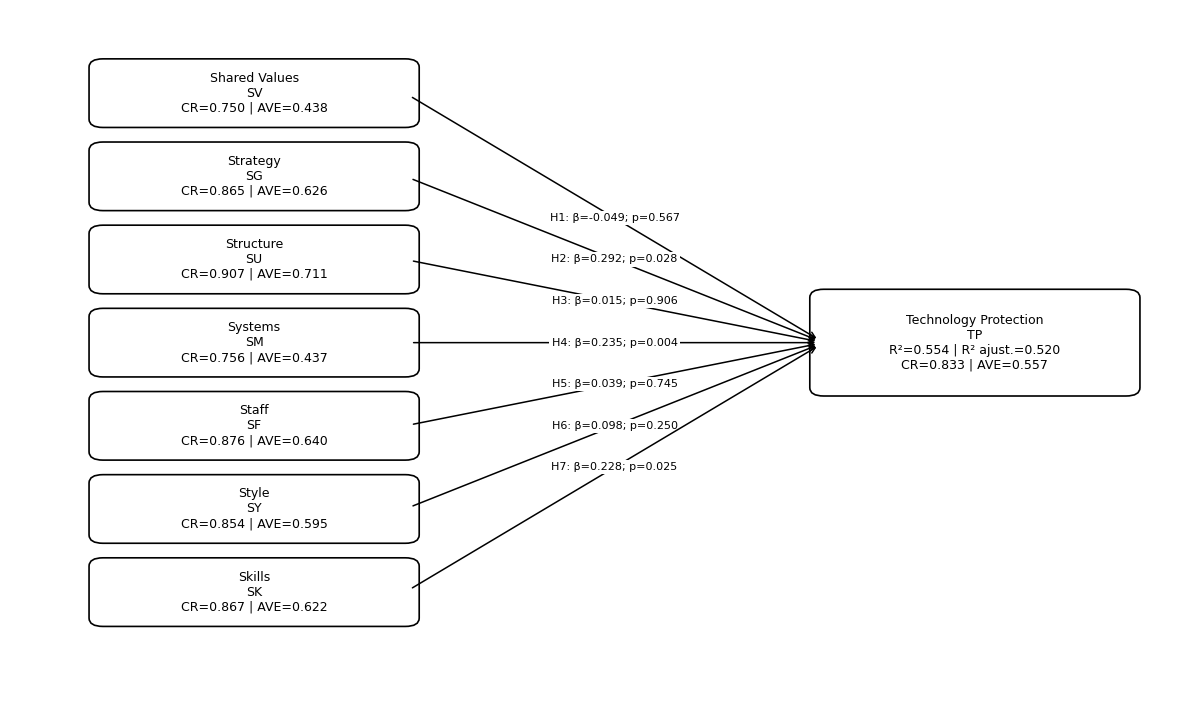

Imagem PNG exportada para: D:\projetos\pessoal\paper_douturado_unb_fhc\code\outputs\grafico_pls_sem.png


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

OUTPUT_DIR = Path(".")
PNG_PATH = OUTPUT_DIR / "outputs/grafico_pls_sem.png"


def export_pls_sem_png(
    path_results: pd.DataFrame,
    reliability_table: pd.DataFrame,
    r2_value: float,
    r2_adj_value: float,
    output_path: Path = PNG_PATH,
) -> Path:
    """Exporta o gráfico PLS-SEM para PNG usando matplotlib.

    O desenho replica os elementos essenciais do diagrama Mermaid:
    constructos, CR, AVE, coeficientes beta, p-value e R² de TP.
    """
    rel = reliability_table.set_index("Constructo")
    paths = path_results.set_index("Constructo")

    fig, ax = plt.subplots(figsize=(15, 9))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    left_x = 0.08
    right_x = 0.70
    box_w = 0.26
    box_h = 0.075

    y_positions = {
        "SV": 0.88,
        "SG": 0.76,
        "SU": 0.64,
        "SM": 0.52,
        "SF": 0.40,
        "SY": 0.28,
        "SK": 0.16,
    }

    def fmt(value: float) -> str:
        return f"{value:.3f}"

    def draw_box(x: float, y: float, width: float, height: float, text: str) -> None:
        patch = FancyBboxPatch(
            (x, y - height / 2),
            width,
            height,
            boxstyle="round,pad=0.012,rounding_size=0.012",
            linewidth=1.2,
            edgecolor="black",
            facecolor="white",
        )
        ax.add_patch(patch)
        ax.text(
            x + width / 2,
            y,
            text,
            ha="center",
            va="center",
            fontsize=9,
        )

    # Nós independentes
    for construct, y in y_positions.items():
        node_text = (
            f"{labels[construct]}\n"
            f"{construct}\n"
            f"CR={fmt(rel.loc[construct, 'CR'])} | AVE={fmt(rel.loc[construct, 'AVE'])}"
        )
        draw_box(left_x, y, box_w, box_h, node_text)

    # Nó dependente
    tp_y = 0.52
    tp_text = (
        f"{labels['TP']}\n"
        f"TP\n"
        f"R²={fmt(r2_value)} | R² ajust.={fmt(r2_adj_value)}\n"
        f"CR={fmt(rel.loc['TP', 'CR'])} | AVE={fmt(rel.loc['TP', 'AVE'])}"
    )
    draw_box(right_x, tp_y, box_w, 0.13, tp_text)

    # Setas e rótulos dos caminhos
    for construct, y in y_positions.items():
        beta = paths.loc[construct, "beta"]
        p_value = paths.loc[construct, "p_boot"]
        h = hypotheses[construct]

        start = (left_x + box_w, y)
        end = (right_x, tp_y)

        ax.annotate(
            "",
            xy=end,
            xytext=start,
            arrowprops=dict(
                arrowstyle="->",
                linewidth=1.1,
                shrinkA=6,
                shrinkB=6,
            ),
        )

        label_x = (start[0] + end[0]) / 2
        label_y = (start[1] + end[1]) / 2
        ax.text(
            label_x,
            label_y,
            f"{h}: β={fmt(beta)}; p={fmt(p_value)}",
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(facecolor="white", edgecolor="none", pad=1.5),
        )

    # ax.set_title(
    #     "PLS-SEM — Modelo 7S para Technology Protection",
    #     fontsize=14,
    #     pad=18,
    # )

    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return output_path


exported_png = export_pls_sem_png(results, reliability, r2, r2_adj, PNG_PATH)

print(f"Imagem PNG exportada para: {exported_png.resolve()}")


## Exportar a tabela formatada para LaTeX

Esta seção gera a tabela de hipóteses em formato LaTeX e salva o arquivo `tabela_pls_sem.tex` no diretório local do notebook.


In [9]:
from pathlib import Path

LATEX_PATH = Path("outputs/hdt_respostas_7s.csvtabela_pls_sem.tex")

table_latex = table_final.copy()

# Formatação textual com três casas decimais.
table_latex["β"] = table_latex["β"].map(lambda x: f"{x:.3f}")
table_latex["p boot"] = table_latex["p boot"].map(lambda x: f"{x:.3f}")

# Nomes de colunas com sintaxe LaTeX.
table_latex = table_latex.rename(
    columns={
        "Hipótese": "Hipótese",
        "Caminho": "Caminho",
        "β": r"$\beta$",
        "p boot": r"$p_{boot}$",
        "Resultado": "Resultado",
    }
)

latex_code = table_latex.to_latex(
    index=False,
    escape=False,
    column_format="llrrl",
    caption="Resultados do modelo PLS-SEM para as hipóteses H1--H7.",
    label="tab:resultados_pls_sem",
)

LATEX_PATH.write_text(latex_code, encoding="utf-8")

print(latex_code)
print(f"Tabela LaTeX exportada para: {LATEX_PATH.resolve()}")


\begin{table}
\caption{Resultados do modelo PLS-SEM para as hipóteses H1--H7.}
\label{tab:resultados_pls_sem}
\begin{tabular}{llrrl}
\toprule
Hipótese & Caminho & $\beta$ & $p_{boot}$ & Resultado \\
\midrule
H1 & SV → TP & -0.049 & 0.567 & Não suportada \\
H2 & SG → TP & 0.292 & 0.028 & Suportada \\
H3 & SU → TP & 0.015 & 0.906 & Não suportada \\
H4 & SM → TP & 0.235 & 0.004 & Suportada \\
H5 & SF → TP & 0.039 & 0.745 & Não suportada \\
H6 & SY → TP & 0.098 & 0.250 & Não suportada \\
H7 & SK → TP & 0.228 & 0.025 & Suportada \\
\bottomrule
\end{tabular}
\end{table}

Tabela LaTeX exportada para: D:\projetos\pessoal\paper_douturado_unb_fhc\code\outputs\hdt_respostas_7s.csvtabela_pls_sem.tex
